# Setup

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pymonntorch
pymonntorch.__version__

'0.1.4'

In [3]:
import torch
from pymonntorch import *
from conex import *

import json

from matplotlib import pyplot as plt
import numpy as np

from Sequence_suppl import Sequence
from Simulation_suppl import Simulation

# Params

In [4]:
from params_6_SNN_suppl import params_base, params_c0, params_c1, params_c2, params_c3

# Activities of examples

In [6]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

### c3

In [14]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(1) : 
    sim = Simulation(params = params_c3)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C3 : Executed on 10 simulations successfully")

C3 : Executed on 10 simulations successfully


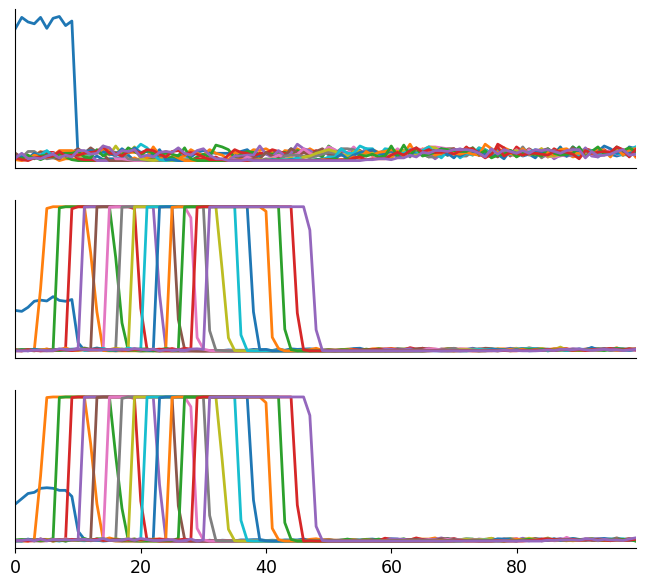

In [11]:
plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
# plt.savefig('./act_c3.svg')
plt.show()

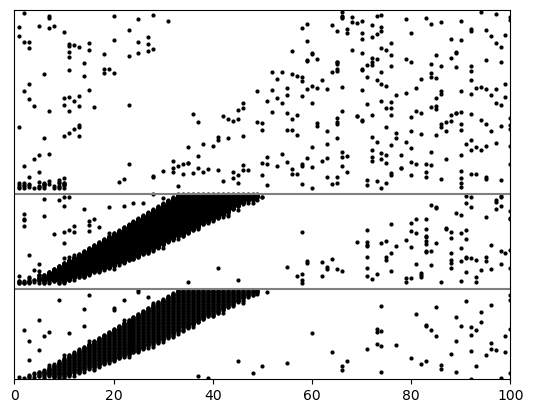

In [13]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

# plt.savefig('./rast_c3.svg')
plt.show()

### c2

In [24]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(1) : 
    sim = Simulation(params = params_c2)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C2 : Executed on 10 simulations successfully")

C2 : Executed on 10 simulations successfully


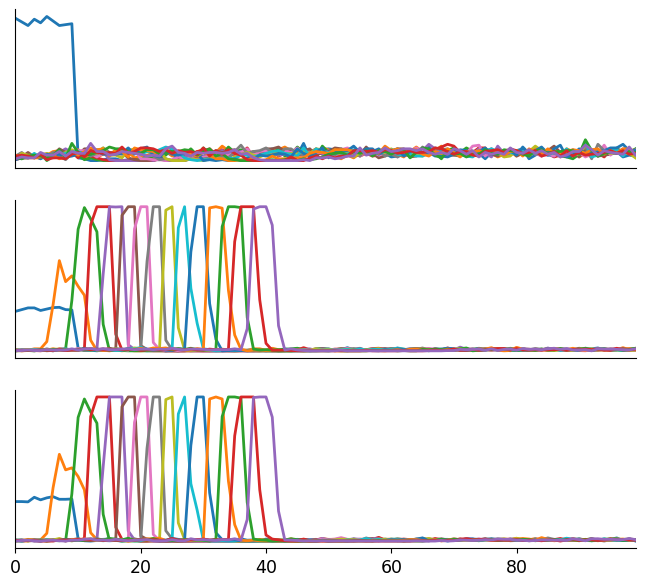

In [21]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])
# plt.ylim(0, 0.52)

plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
# plt.savefig('./act_c2.svg')
plt.show()

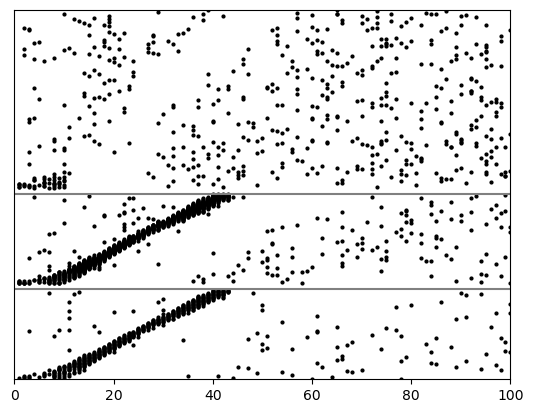

In [23]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

# plt.savefig('./rast_c2.svg')
plt.show()

### c1

In [25]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

for _ in range(1) : 
    sim = Simulation(params = params_c1)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C1 : Executed on 10 simulations successfully")

C1 : Executed on 10 simulations successfully


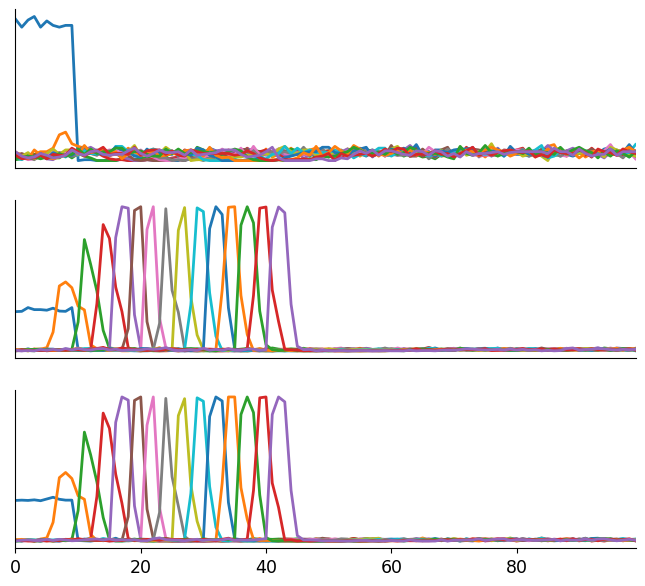

In [19]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
# plt.savefig('./act_c1.svg')
plt.show()

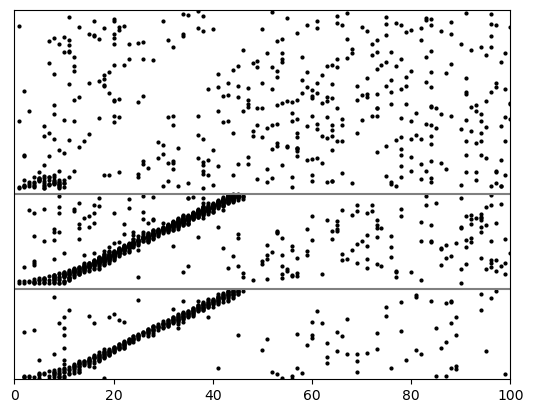

In [18]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

# plt.savefig('./rast_c1.svg')
plt.show()

### c0

In [26]:
base_line_strong = []
base_line_weak_1 = []
base_line_weak_2 = []
for i in range(N_ASSEMBLE) :
    base_line_strong.append(torch.zeros(100))
    base_line_weak_1.append(torch.zeros(100))
    base_line_weak_2.append(torch.zeros(100))

# params_c0["P_RC"] = 0.035
params_c0["COOP21"] = params_c0["COOP12"] = 0.025
params_c0["P_RC"] = 0.033
for _ in range(1) : 
    sim = Simulation(params = params_c0)
    result, weak_seq_1, weak_seq_2, strong_seq = sim.run()

    for i in range(N_ASSEMBLE) :
        base_line_strong[i] += ((strong_seq.assemblies[i][0]["torch.sum(spikes)"][0])/(STRONG_SIZE_E))
        base_line_weak_1[i] += ((weak_seq_1.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))
        base_line_weak_2[i] += ((weak_seq_2.assemblies[i][0]["torch.sum(spikes)"][0])/(WEAK_SIZE_E))

print("C0 : Executed on 10 simulations successfully")

C0 : Executed on 10 simulations successfully


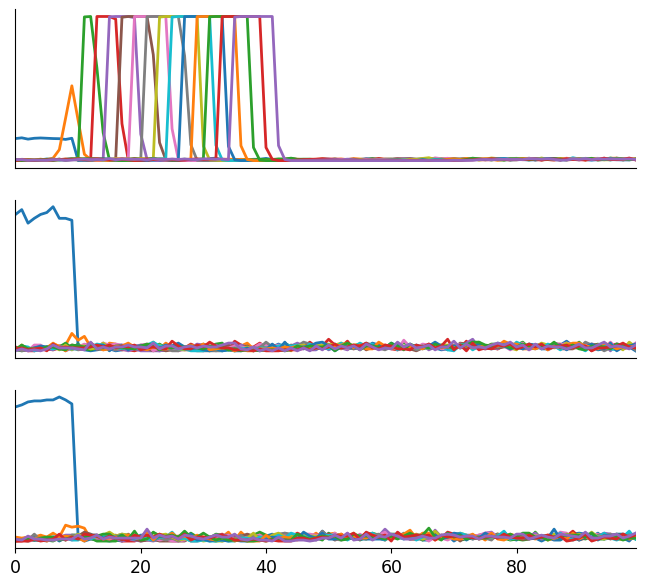

In [31]:
N_ASSEMBLE = 30

STRONG_SIZE_E = 1000
STRONG_SIZE_I = 250

WEAK_SIZE_E = 500
WEAK_SIZE_I = 125

plt.figure(figsize=(8, 7))

mult = 2

plt.subplot(3, 1, 1)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)


for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_strong[i] / 10, linewidth = 2)

plt.xticks([])
plt.yticks([])
# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 2)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_1[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])
plt.xticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)

plt.subplot(3, 1, 3)
for i in range(N_ASSEMBLE) : 
    if(i % mult == 0) : 
        plt.plot(base_line_weak_2[i] / 10, linewidth = 2)

plt.gca().spines["top"].set_visible(False)
plt.gca().spines["right"].set_visible(False)
plt.yticks([])

# plt.ylim(0, 0.52)
plt.xlim(0, 99)
plt.xticks(fontsize=12.5)

  
plt.savefig('./act_c0.svg')
plt.show()

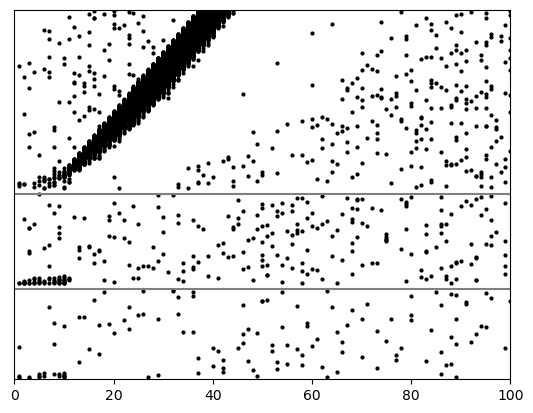

In [32]:
mult = 1

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_2.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 100 == 4][:, 0], x[x[:, 1] % 100 == 4][:, 1] + i//mult * (WEAK_SIZE_E), 'o',markersize = 2, alpha = 1, color = "black")
# plt.show()

for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = weak_seq_1.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i//mult * (WEAK_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE//mult + 1000, 'o',markersize = 2, alpha = 1, color = "black")

# plt.show()
for i in range(N_ASSEMBLE) : 
    if(i % mult != 0) : 
        continue
    candy = strong_seq.assemblies[i][0]["spikes", 0]
    x = candy.clone().detach()

    plt.plot(x[x[:, 1] % 50 == 4][:, 0], x[x[:, 1] % 50 == 4][:, 1] + i * (STRONG_SIZE_E) + (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 2000, 'o',markersize = 2, alpha = 1, color = "black")

plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 1//mult , color = 'gray', linestyle = '-') 
plt.axhline(y = (WEAK_SIZE_E) * N_ASSEMBLE * 2//mult + 1000, color = 'gray', linestyle = '-') 

# disabling xticks by Setting xticks to an empty list
plt.ylim(-100, 62000)
plt.xlim(0, 100)
# plt.xticks([])  
 
# disabling yticks by setting yticks to an empty list
plt.yticks([])  

plt.savefig('./rast_c0.svg')